# Unsupervised Learning: 
## Application of Graphical Network Analysis on Stock Returns Data

Last Update: July 24th, 2020


### Before You Start
This jupyter notebook is mainly designed for illustration purpose. Readers are supposed to run the code block by block from the start to the end. Skipping running any line of the code may cause error thereafter.

Readers should not modify the code, unless the block is marked by CAN BE CHANGED.

Readers are encourage to run the code with the existing value in the CAN BE CHANGED block before having gone through the entire notebook. Once the some block is modified, readers should run its following blocks to see the changes.

## 1. Set Up Environment and Read Data

### 1.0 Model Setup
For the first step, let's import necessary packages and import our functions (for later use):

In [ ]:
# Import all the necessary packages

import numpy as np #for numerical array data
import pandas as pd #for tabular data
import matplotlib.pyplot as plt #for plotting purposes
import csv
from datetime import datetime, timedelta

from sklearn import cluster, covariance, manifold
from matplotlib.collections import LineCollection #for plotting purposes

import warnings
warnings.filterwarnings('ignore')
import os

%load_ext autoreload
%autoreload 2

In [153]:
# Import the self-defined function from the python file
from Graphical_Analysis_functions import *

In [ ]:
def load_json_candles(fname):
    data = pd.read_json(fname)
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

def load_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/{base}_{quote}-{timeframe}.json'
    return load_json_candles(fname)

def load_futures_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/futures/{base}_{quote}_{quote}-{timeframe}-futures.json'
    return load_json_candles(fname)

def load_sp500_stock_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/sp500_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

def load_russel2000_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/russell_2000_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

In [171]:
# def tpose(l) : list(map(list, zip(*l)))
with open('/media/mu6mula/Data/Crypto-Data-Feed/top100MarketCap.txt', 'r') as file:
    coins = [c for c in [l[:-1] for l in file.readlines()] if not c in ['USDT']]
exchange,quote,timeframe = 'binance', 'USDT', '1d'
data_folder = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}'
bf = ([ (b,f) for (b,f) in [(base, f'{data_folder}/{base}_{quote}-{timeframe}.json') for base in coins] if os.path.exists(f) ])
coins, files =list(map(list, zip(*bf)))
# .assign(ts=lambda df:pd.to_datetime(df.index,unit='ms'))
dfs = [pd.read_json(f)[[0,4]].set_axis(['ts','close'],axis=1).set_index('ts') for f in files]

(array([28., 28., 28., 28., 28., 28., 30., 34., 38., 42., 44., 45., 45.,
        45., 46., 46., 48., 49., 51., 53., 54., 54., 56., 56., 57., 59.,
        59., 59., 61., 61., 61., 61., 62., 64., 64., 64., 64., 64., 65.,
        65., 66., 66., 68., 69., 69., 70., 72., 74., 75., 79.]),
 array([1.57783680e+12, 1.58046509e+12, 1.58309338e+12, 1.58572166e+12,
        1.58834995e+12, 1.59097824e+12, 1.59360653e+12, 1.59623482e+12,
        1.59886310e+12, 1.60149139e+12, 1.60411968e+12, 1.60674797e+12,
        1.60937626e+12, 1.61200454e+12, 1.61463283e+12, 1.61726112e+12,
        1.61988941e+12, 1.62251770e+12, 1.62514598e+12, 1.62777427e+12,
        1.63040256e+12, 1.63303085e+12, 1.63565914e+12, 1.63828742e+12,
        1.64091571e+12, 1.64354400e+12, 1.64617229e+12, 1.64880058e+12,
        1.65142886e+12, 1.65405715e+12, 1.65668544e+12, 1.65931373e+12,
        1.66194202e+12, 1.66457030e+12, 1.66719859e+12, 1.66982688e+12,
        1.67245517e+12, 1.67508346e+12, 1.67771174e+12, 1.68034003e+

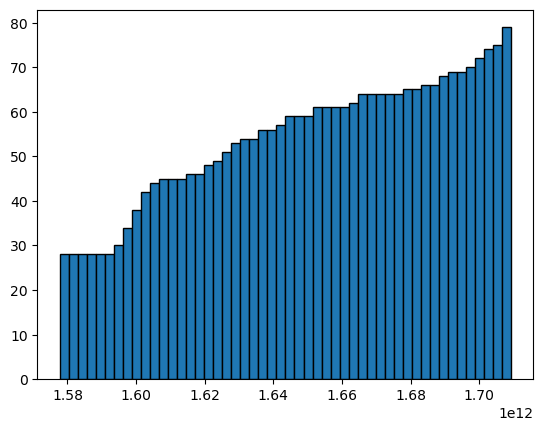

In [172]:
# inspect starting dates
counts, bin_edges = np.histogram([d.index[0] for d in dfs], bins=25)
plt.hist([d.index[0] for d in dfs], bins=50, cumulative=True, edgecolor='black')

In [173]:
# select a starting period with > 50 tickers
first_quantile = np.quantile([d.index[0] for d in dfs], 0.7)
print(f'first_quantile: {first_quantile}')
fadfs = [(coins[i], df) for (i,df) in enumerate(dfs) if df.index[0]<=first_quantile]
fcoins, fdfs = list(map(list, zip(*fadfs)))
len(fcoins)

first_quantile: 1637383680000.0


55

In [174]:
df = pd.concat(fdfs,axis=1).set_axis(fcoins,axis=1)
df.set_index(pd.to_datetime(df.index,unit='ms'),inplace=True)
df
# df['IMX'].plot()#.dropna()
df.dropna(inplace=True,axis=0)
# df = df.resample(f'1W').last()#.agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
# df.isna().sum()
df

,BTC,ETH,BNB,SOL,XRP,USDC,ADA,AVAX,DOGE,LINK,...,NEO,CFX,EOS,IOTA,ROSE,KAVA,KLAY,GALA,GNO,ENS
ts,,,,,,,,,,,,,,,,,,,,,
2021-11-10,64882.43,4628.78,614.1,233.09,1.1902,0.9997,2.0970,85.23,0.25530,34.21,...,48.22,0.3124,4.8410,1.2957,0.19673,5.4870,1.5070,0.08203,479.6,73.82
2021-11-11,64774.26,4719.00,628.4,233.37,1.2142,0.9994,2.0790,87.88,0.26050,34.69,...,48.52,0.3133,4.9220,1.3297,0.23000,5.5880,1.5570,0.08602,481.8,55.31
2021-11-12,64122.23,4665.46,626.9,228.48,1.1883,1.0000,2.0450,84.78,0.25930,34.26,...,47.31,0.3125,4.8490,1.2837,0.22494,5.5900,1.5370,0.08418,477.1,54.65
2021-11-13,64380.00,4644.28,649.5,241.59,1.1892,0.9998,2.0500,97.54,0.26130,34.00,...,49.05,0.3112,5.0090,1.3164,0.22969,5.6630,1.5310,0.09418,467.2,55.57
2021-11-14,65519.10,4626.50,650.8,238.64,1.1879,0.9997,2.0400,95.40,0.26280,33.75,...,48.48,0.3144,4.9570,1.3045,0.22488,5.6560,1.4970,0.09329,464.2,56.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-03,60697.99,2903.64,529.6,142.52,0.5558,1.0006,0.3646,22.67,0.10811,11.68,...,9.58,0.1315,0.4957,0.1341,0.06695,0.3344,0.1279,0.01858,180.4,20.65
2024-08-04,58161.00,2688.92,496.9,138.33,0.5228,1.0003,0.3442,21.25,0.10375,10.88,...,9.15,0.1265,0.4711,0.1278,0.06438,0.3108,0.1225,0.01756,166.6,18.55
2024-08-05,54018.81,2419.59,464.2,129.78,0.4889,0.9996,0.3119,19.54,0.09436,9.49,...,8.53,0.1171,0.4450,0.1205,0.05692,0.2826,0.1168,0.01570,151.4,16.46


In [ ]:
# data = df.pct_change()
# data.head()

In [ ]:
data = df.pct_change()
# Plot cumulative return for each firm
lo_col = 4
lo_row = int(np.ceil(len(df.columns)/4))
f_hei = lo_row * 2.5
f_wid = lo_col * 4
ax = (data+1).cumprod().plot(subplots=True, layout=(lo_row, lo_col), figsize=(f_wid, f_hei),
                             logy=True, sharex=True, sharey=True,
                             title='Cumulative Return for Individual Stock (Weekly, Log-scale)');
for i in range(lo_col):
    ax[0,i].xaxis.set_tick_params(which='both', top = True, labeltop=True, labelrotation=40)
plt.show()

## 2. Graphical Analysis

Below we will introduce a graphical analysis algorithm and apply it on the weekly stock returns data. The algorithm employs several unsupervised learning techniques and combine them together to visualize the stock returns data.

The algorithm takes the weekly returns of the stocks as input, and feeds it into three unsupervised learning techniques in order. The three techniques are:

- ***Sparse Inverse Covariance Estimation*** is used on the returns data, and it outputs a sparse matrix whose elements represent the conditional correlation between any two stock returns.
    - It provides information about which stocks are correlated conditionally on the others, and we can use this information to construct the graphical network.
        - The estimator we used in this graphical analysis example is called **Graphical Lasso**, which uses an l1 penalty to enforce sparsity on the precision matrix.
- ***Affinity Propagation***, like K-Means, is a clustering method that organizes the returns into clusters. It does not enforce equal-size clusters, and it can choose automatically the number of clusters from the data.
    - Stock returns that are clustered together can be considered as having a similar impact at the level of the full stock market.
- ***Manifold Learning*** is a non-linear embedding method that projects a high-dimensional graph onto 2D plane. The 2D graph is then constructed by combining the results from the above techniques in the following way:
    - Each node corresponds to a stock, with color being defined by the cluster label from Affinity Propagation.
    - Each edge links two stocks. 
        - The **strength** of the edge is defined by the sparse inverse covariance matrix (i.e. the precision matrix). The higher the value is, the more conditional correlated it is for the two stocks.
    - The Maniford 2D embedding is used to position the nodes on the plane.
        - The Manifold learning method we used in this graphical analysis example is called **Multidimensional scaling (MDS)**, which seeks a low-dimensional representation of the data in which the distances respect well the distances in the original high-dimensional space

The source code is wrapped up in Graphical_Analysis_functions.py, and is beyond the scope of the course. Interested readers can find more information and read about the above three techniques.

References: 
- https://scikit-learn.org/stable/auto_examples/applications/plot_stock_market.html
- https://scikit-learn.org/stable/modules/covariance.html#sparse-inverse-covariance
- https://scikit-learn.org/stable/modules/clustering.html#affinity-propagation
- https://scikit-learn.org/stable/modules/manifold.html#multi-dimensional-scaling-mds


Recall that the sectors available in this dataset are:

### First Data Analysis

Specifications:
- Enter some specific dates in the "**start_date**" and "**end_date**" to specify the start and end date.
- By default ( i.e. **Sectors_chosen** = [] ), ALL sectors will be included in the graphical analysis.
    - if certain sectors are entered in the "**Sectors_chosen**" option, then only those sectors will be examined in the graphical network analysis.
    - e.g: Sectors_chosen = ['Bank','Tech']
        - Only the Bank and Tech sectors will be examined.
- By default ( i.e. **drop_firm** = [] ), ALL firms in the given sectors (specified in "**Sectors_chosen**") will be included in the graphical analysis.
    - if certain firms are entered in the "**drop_firm**" option, then only those firms will NOT be examined in the graphical network analysis.
    - e.g: drop_firm = ['FRC','RY']
        - 'FRC' and 'RY' will not be examined.
- By default (i.e. **display_SumStat** = True, **display_IndRet** = True), the summary statisitcs and the individual firm performance (individual firm's cumulative returns) will be displayed

In [163]:
###########################################   CAN BE CHANGED  #############################################

## Start and End date we are considering:
# start_date = '2020-01-01'
# end_date   = '2020-06-28'
start_date = '2015-07-01'
end_date   = '2025-06-28'

## Sectors which we will be testing:
# Sectors_chosen = ['Bank','Health','Energy','Tech']
# Sectors_chosen = ['Bank','Health','Energy','Tech','Market Index']
Sectors_chosen = []


## The list of firms we want to drop:
# drop_firm = ['SP500']
drop_firm = []

## Whether we want to display the summary statisitcs and/or individual firm performance:
display_SumStat = False
display_IndRet = False

###########################################   CAN BE CHANGED  #############################################

Results over the time period  2015-07-01  to  2025-06-28 :

Number of assets examined: 55
Cluster 1: BTC, ETH, BNB, MATIC, GRT, AAVE, SNX, NEO, GNO, ENS
Cluster 2: USDC
Cluster 3: DOGE, SHIB, BCH, LTC, FTM, KLAY
Cluster 4: TRX
Cluster 5: ICP
Cluster 6: STX, INJ, CFX
Cluster 7: MKR
Cluster 8: TUSD
Cluster 9: SOL, XRP, ADA, AVAX, LINK, DOT, UNI, ATOM, ETC, NEAR, XLM, VET, FIL, HBAR, RUNE, EGLD, MINA, ALGO, FLOW, QNT, THETA, AXS, SAND, XTZ, CHZ, MANA, EOS, IOTA, ROSE, KAVA
Cluster 10: GALA


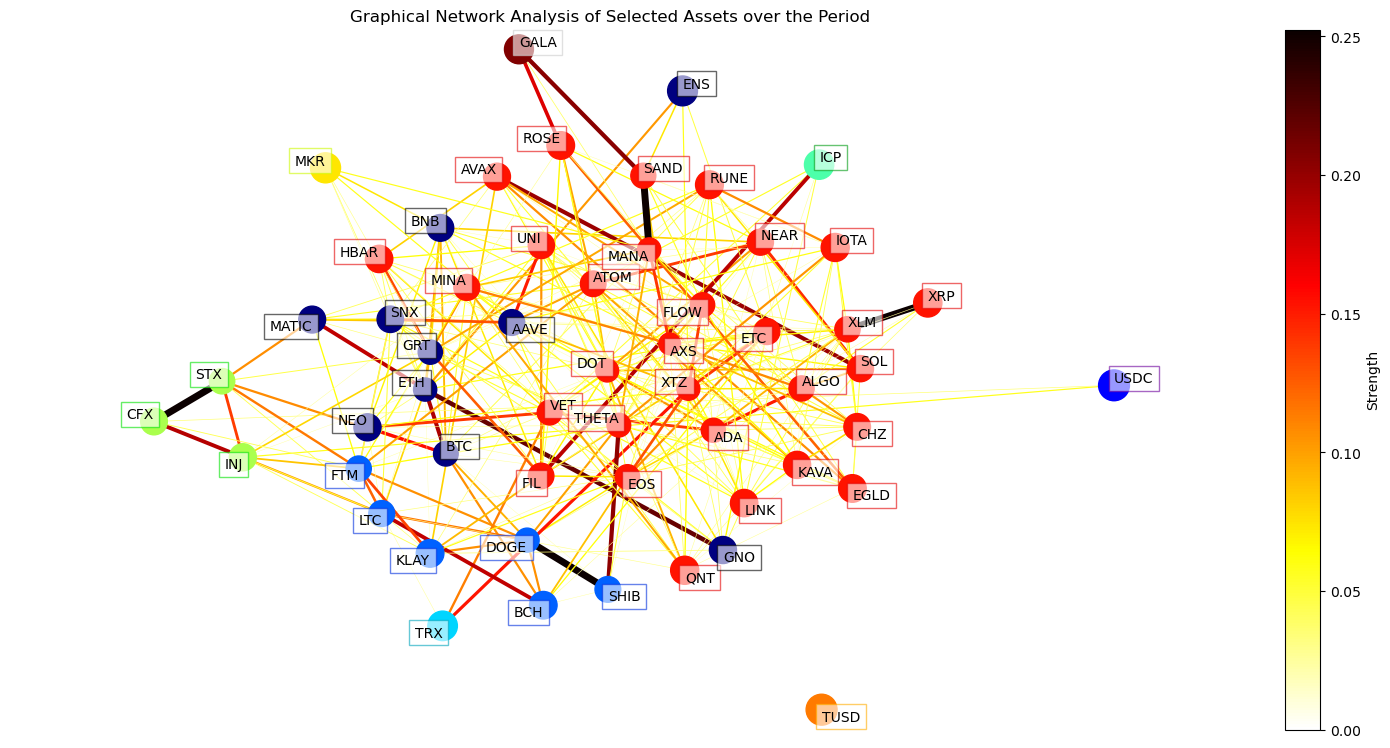

In [169]:
print('Results over the time period ', start_date, ' to ', end_date, ':')
print()

dataset = data = df.pct_change().dropna()
# data_rf = pd.DataFrame({'r':0},index=dataset.index)

# Output the Clustering information, graphical network plot, 
# as well as summary statistics (optional) and the individual firm performance (optional)
# Store the correlation matrix and precision matrix in "est" (stands for estimates)
# Store the plotting configuration information in "con_fig" which will be needed if we want to use the ZOOM functions
## Note: you can view the correlation matrix by looking at est[0] and view the precision matrix by looking at est[1] 
est, con_fig = graphicalAnalysis(data)

Results over the time period  2015-07-01  to  2025-06-28 :

Number of assets examined: 55
Cluster 1: BTC, ETH, BNB, MATIC, GRT, AAVE, SNX, NEO, GNO, ENS
Cluster 2: USDC
Cluster 3: DOGE, SHIB, BCH, LTC, FTM, KLAY
Cluster 4: TRX
Cluster 5: ICP
Cluster 6: STX, INJ, CFX
Cluster 7: MKR
Cluster 8: TUSD
Cluster 9: SOL, XRP, ADA, AVAX, LINK, DOT, UNI, ATOM, ETC, NEAR, XLM, VET, FIL, HBAR, RUNE, EGLD, MINA, ALGO, FLOW, QNT, THETA, AXS, SAND, XTZ, CHZ, MANA, EOS, IOTA, ROSE, KAVA
Cluster 10: GALA


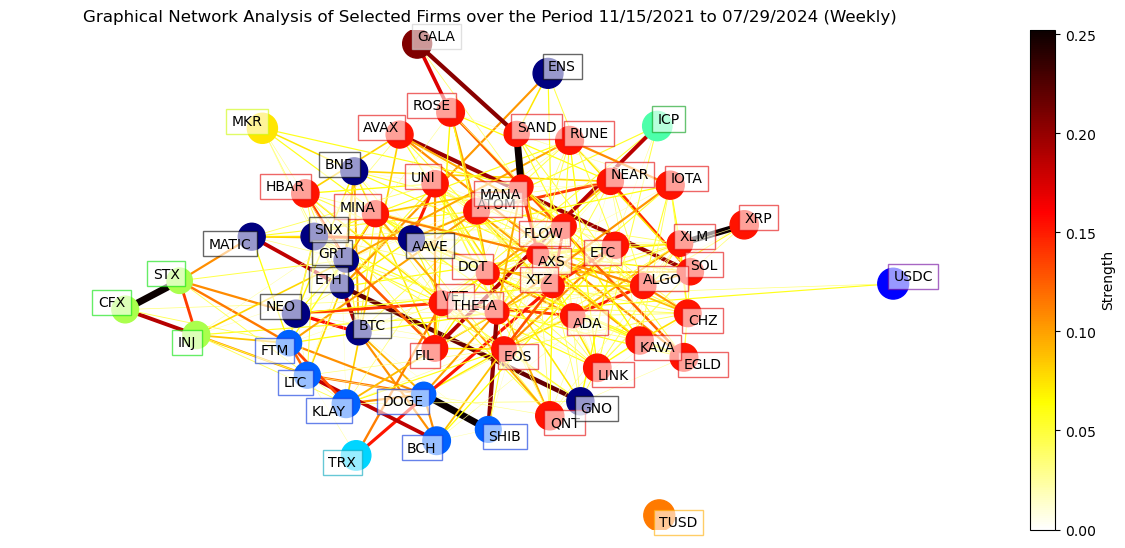

([array([[0.99166667, 0.45308791, 0.3300122 , ..., 0.09180234, 0.25916992,
          0.12618438],
         [0.45308791, 0.99166667, 0.34975487, ..., 0.10054588, 0.40881719,
          0.2071808 ],
         [0.3300122 , 0.34975487, 0.99166667, ..., 0.08853091, 0.21175535,
          0.10689161],
         ...,
         [0.09180234, 0.10054588, 0.08853091, ..., 0.99166667, 0.07673366,
          0.05952083],
         [0.25916992, 0.40881719, 0.21175535, ..., 0.07673366, 0.99166667,
          0.11577011],
         [0.12618438, 0.2071808 , 0.10689161, ..., 0.05952083, 0.11577011,
          0.99166667]]),
  array([[ 1.58577411, -0.32249956, -0.13318885, ..., -0.        ,
          -0.01363501, -0.        ],
         [-0.32249956,  1.79654153, -0.14763699, ..., -0.        ,
          -0.33421844, -0.14330303],
         [-0.13318885, -0.14763699,  1.34745211, ..., -0.        ,
          -0.        , -0.        ],
         ...,
         [-0.        , -0.        , -0.        , ...,  1.15240517,
   

In [164]:
print('Results over the time period ', start_date, ' to ', end_date, ':')
print()

dataset = data = df.pct_change().dropna()
data_rf = pd.DataFrame({'r':0},index=dataset.index)

# Output the Clustering information, graphical network plot, 
# as well as summary statistics (optional) and the individual firm performance (optional)
# Store the correlation matrix and precision matrix in "est" (stands for estimates)
# Store the plotting configuration information in "con_fig" which will be needed if we want to use the ZOOM functions
## Note: you can view the correlation matrix by looking at est[0] and view the precision matrix by looking at est[1] 
est, con_fig = graphicalAnalysis(data, start_date, end_date, 
                                 Sectors_chosen, drop_firm, 
                                 display_SumStat, display_IndRet)



display_IndRet = False
# def graphicalAnalysis(dataset, start_date, end_date , 
#                       Sectors_chosen = [],
#                       drop_firm = [], 
#                       display_SumStat = True, display_IndRet = True, 
#                       data_rf = None #df_rf
#                       ):
# X = dataset

# # Check if there is NA in the dataset within the given time period
# # If yes, then drop those firms before doing graphical analysis
# if(X.isnull().values.any()):
#     print('WARNING: Some firms have missing data during this time period!')
#     print('Dropping firms: ')
#     for Xcol_dropped in list(X.columns[X.isna().any()]): print(Xcol_dropped)
#     X = X.dropna(axis='columns')
#     print()

# # Get the Start and End date of the dataset
# date_obj = X.index[0]
# start_of_week = date_obj - timedelta(days=date_obj.weekday())
# start = start_of_week.strftime("%m/%d/%Y")
# end =  X.index[-1].strftime("%m/%d/%Y")

# # Get the firm names of the dataset
# names = np.array(list(X.columns))

# # Show the number of firms examined
# print('Number of assets examined:', X.shape[1])


# # #############################################################################
# # Learn a graphical structure from the correlations

# # Graphical Lasso is used here to estimate the precision matrix    
# edge_model = covariance.GraphicalLassoCV(max_iter=1000)

# # standardize the time series: 
# # using correlations rather than covariance is more efficient for structure recovery
# X_std = X / X.std(axis=0)
# edge_model.fit(X_std)

# # #############################################################################
# # Cluster using affinity propagation

# _, labels = cluster.affinity_propagation(edge_model.covariance_)
# n_labels = labels.max()

# for i in range(n_labels + 1):
#     print('Cluster %i: %s' % ((i + 1), ', '.join(names[labels == i])))

# # #############################################################################
# # Find a low-dimension embedding for visualization: find the best position of
# # the nodes (the stocks) on a 2D plane

# node_position_model = manifold.MDS(n_components=2, random_state=0)
# embedding = node_position_model.fit_transform(X_std.T).T

# # #############################################################################
# # Visualization I

# # Specify node colors by cluster labels 
# color_list = pl.cm.jet(np.linspace(0,1,n_labels+1))
# my_colors = [color_list[i] for i in labels]

# # Compute the partial correlations
# partial_correlations = edge_model.precision_.copy()
# d = 1 / np.sqrt(np.diag(partial_correlations))
# partial_correlations *= d
# partial_correlations *= d[:, np.newaxis]
# non_zero = (np.abs(np.triu(partial_correlations, k=1)) > 0.02)

# # Compute the edge values based on the partial correlations
# values = np.abs(partial_correlations[non_zero])
# val_max = values.max()

# # Title of the plot
# title = 'Graphical Network Analysis of Selected Firms over the Period '+start+' to '+end+' (Weekly)'

# # Display the partial correlation graph
# graphicalAnalysis_plot(d, partial_correlations, my_colors,
#                         names, labels, embedding, val_max, title)

# # The configuration of the plot
# plot_config = [d, partial_correlations, my_colors, names, labels, embedding, val_max, title]

# # #############################################################################
# # Visualization II

# # For individual firm performance over the given period
# if (display_IndRet):
#     print('Individual Stock Performance over the Period '+ start+' to '+end+' (Weekly):')
#     l_r = int(np.ceil(len(names)/4))
#     l_c = 4
#     f_hei = l_r * 2.5
#     f_wid = l_c * 4
#     ax = (X+1).cumprod().plot(subplots=True, layout=(l_r, l_c), figsize=(f_wid, f_hei),
#                                 logy=True, sharex=True, sharey=True, x_compat=True,
#                                 color = my_colors);
#     for i in range(l_c):
#         ax[0,i].xaxis.set_tick_params(which='both', top = True, labeltop=True, labelrotation=40)
#     plt.show()

# # #############################################################################
# # Show summary statistics for each firm over the given period
# # if (display_SumStat):
# #     display(getSumStat(X, rf = data_rf2['T-Bill']))

# # return [edge_model.covariance_, edge_model.precision_], plot_config
# # END of function graphicalAnalysis
# # #############################################################################

# [edge_model.covariance_, edge_model.precision_], plot_config

We can use the following code to ZOOM IN and focus on a particular sector (or sectors) from the given network graph (above).

In [ ]:
###########################################   CAN BE CHANGED  #############################################

## The list of Sector(s) we want to look at more closely
Sectors_list = ['Bank']

###########################################   CAN BE CHANGED  #############################################

In [ ]:
graphicalAnalysis_plot_ZOOM_bySector(Sectors_list, con_fig)

We can also use the following code to ZOOM IN and focus on a particular set of firms from the given network graph.

In [ ]:
###########################################   CAN BE CHANGED  #############################################

## The list of firms we want to look at more closely
# Note: These firms don't have to be from the same sector 
# (but they need to be in the "Sectors_chosen" list if "Sectors_chosen" is different from default setting)

firms_list = ['FRC','JPM','BAC', 'GS', 'MS', 'PNC','C']

###########################################   CAN BE CHANGED  #############################################

In [ ]:
print('ZOOM IN View of the Selected Firms:')
print(firms_list)
graphicalAnalysis_plot_ZOOM_byFirm(firms_list, con_fig)

### Second Data Analysis

Recall:

Specifications:
- Enter some specific dates in the "**start_date**" and "**end_date**" to specify the start and end date.
- By default ( i.e. **Sectors_chosen** = [] ), ALL sectors will be included in the graphical analysis.
    - if certain sectors are entered in the "**Sectors_chosen**" option, then only those sectors will be examined in the graphical network analysis.
    - e.g: Sectors_chosen = ['Bank','Tech']
        - Only the Bank and Tech sectors will be examined.
- By default ( i.e. **drop_firm** = [] ), ALL firms in the given sectors (specified in "**Sectors_chosen**") will be included in the graphical analysis.
    - if certain firms are entered in the "**drop_firm**" option, then only those firms will NOT be examined in the graphical network analysis.
    - e.g: drop_firm = ['FRC','RY']
        - 'FRC' and 'RY' will not be examined.
- By default (i.e. **display_SumStat** = True, **display_IndRet** = True), the summary statisitcs and the individual firm performance (individual firm's cumulative returns) will be displayed

In [ ]:
###########################################   CAN BE CHANGED  #############################################

## Start and End date we are considering:
start_date = '2015-07-01'
end_date   = '2020-06-28'

## Sectors which we will be testing:
Sectors_chosen = ['Bank','Health','Energy','Tech']

## The list of firms we want to drop:
drop_firm = []

## Whether we want to display the summary statisitcs and/or individual firm performance:
display_SumStat = True
display_IndRet = True

###########################################   CAN BE CHANGED  #############################################

In [ ]:
print('Results over the time period ', start_date, ' to ', end_date, ':')
print()
est, con_fig = graphicalAnalysis(data, start_date, end_date, 
                                 Sectors_chosen, drop_firm, 
                                 display_SumStat, display_IndRet)

Algain, We can use the following code to ZOOM IN and focus on a particular sector (or sectors) from the given network graph (above).

In [ ]:
###########################################   CAN BE CHANGED  #############################################

## The list of Sector(s) we want to look at more closely:
Sectors_list = ['Bank']

###########################################   CAN BE CHANGED  #############################################

In [ ]:
graphicalAnalysis_plot_ZOOM_bySector(Sectors_list, con_fig)

In [ ]:
###########################################   CAN BE CHANGED  #############################################

## The list of firms we want to look at more closely
# Note: These firms don't have to be from the same sector

firms_list = ['FRC','PNC','USB','BAC', 'GS','JPM','C','MS']

###########################################   CAN BE CHANGED  #############################################

In [ ]:
print('ZOOM IN View of the Selected Firms:')
print(firms_list)
graphicalAnalysis_plot_ZOOM_byFirm(firms_list, con_fig)

### Single Stock Analysis: Focusing on a particular firm

Note that some firms have missing data for the whole time period given in the dataset. 

We can change the time period to the starting date of a given firm's data, so that one can examine the graphical analysis results for that particular firm.

In [ ]:
###########################################   CAN BE CHANGED  #############################################

firm_name = 'FRC'

###########################################   CAN BE CHANGED  #############################################

In [ ]:
# Output the index (or date) of the first datapoint for given firm's returns
data[firm_name].first_valid_index()

In [ ]:
###########################################   CAN BE CHANGED  #############################################

## Start and End date we are considering:
start_date = '2010-12-12'
end_date   = '2020-06-28'

## Sectors which we will be testing:
Sectors_chosen = ['Bank','Health','Energy','Tech']

## The list of firms we want to drop:
drop_firm = []

## Whether we want to display the summary statisitcs and/or individual firm performance:
display_SumStat = True
display_IndRet = True

###########################################   CAN BE CHANGED  #############################################

In [ ]:
print('Graphical analysis results over the time period ', start_date, ' to ', end_date, ' for ', firm_name, ':')
print()
est, con_fig = graphicalAnalysis(data, start_date, end_date, 
                                 Sectors_chosen, drop_firm, 
                                 display_SumStat, display_IndRet)

ZOOM IN and focus on the Bank sector from the given network graph (above).

In [ ]:
###########################################   CAN BE CHANGED  #############################################

## The list of Sector(s) we want to look at more closely
Sectors_list = ['Bank']

###########################################   CAN BE CHANGED  #############################################

In [ ]:
graphicalAnalysis_plot_ZOOM_bySector(Sectors_list, con_fig)

In [ ]:
###########################################   CAN BE CHANGED  #############################################

## The list of firms we want to look at more closely
# Note: These firms don't have to be from the same sector
firms_list = ['FRC','PNC', 'USB', 'BAC', 'GS']

###########################################   CAN BE CHANGED  #############################################

In [ ]:
print('ZOOM IN View of the Selected Firms:')
print(firms_list)
graphicalAnalysis_plot_ZOOM_byFirm(firms_list, con_fig)